In [1]:
"""
Massively Parallel Sequential Multiple Testing with E-Values

Demonstrates the full parallel sequential testing framework:
- 10,000 simultaneous hypothesis tests (1,000 true alternatives + 9,000 nulls)
- Three combiner strategies: ALL_IN, CONSERVATIVE, EMPIRICALLY_ADAPTIVE
- Alternative directions: TWO_SIDED, GREATER, LESS
- Extracting e-values, e-processes, sequential e-values, p-values, stopping times, lambdas
- Cross-test error control: e-BH (FDR), e-Bonferroni (FWER), e-Holm (FWER)

References:
    Ramdas & Wang (2025). Hypothesis testing with e-values.
        - Ch. 4: Multiple testing with e-values
        - Ch. 7: E-processes and sequential e-values
    Howard, Ramdas, McAuliffe, Sekhon (2022). Time-uniform confidence sequences.
    Waudby-Smith & Ramdas (2024). Estimating means by betting.
"""

import numpy as np
import matplotlib.pyplot as plt

from expectation.par_seqtest import (
    AlternativeDirection,
    CombinerStrategy,
    MartingaleType,
    MultipleTestingMethod,
    ParallelSequentialTest,
    ParallelTestConfig,
)

# 1. Setup: Null vs Alternative Mixture

We run 10,000 tests simultaneously:
- **1,000 alternatives** (tests 0-999): true mean = 0.5 (H1: mu > 0)
- **9,000 nulls** (tests 1000-9999): true mean = 0.0 (H0: mu = 0)

All tests use known variance = 1.0. The engine tests H0: mu = 0 for each test.

In [2]:
np.random.seed(42)

N_TESTS = 10_000
N_SIGNAL = 1_000
N_NULL = N_TESTS - N_SIGNAL
SIGNAL_STRENGTH = 0.5  # true mean under H1
N_STEPS = 100
ALPHA = 0.05

config = ParallelTestConfig(
    n_tests=N_TESTS,
    alpha=ALPHA,
    v_opt=1.0,
    alpha_opt=0.05,
    martingale_type=MartingaleType.TWO_SIDED_NORMAL,
    alternative=AlternativeDirection.TWO_SIDED,
    combiner=CombinerStrategy.ALL_IN,
)

pst = ParallelSequentialTest(config=config, null_values=0.0, variance=1.0)
print(f"Engine: {pst.n_tests} tests, alpha={pst.alpha}, time_step={pst.time_step}")
print(f"Config: {config.martingale_type}, {config.alternative}, {config.combiner}")

Engine: 10000 tests, alpha=0.05, time_step=0
Config: MartingaleType.TWO_SIDED_NORMAL, AlternativeDirection.TWO_SIDED, CombinerStrategy.ALL_IN


# 2. Sequential Streaming: Feed Observations One Step at a Time

Each `step()` processes one observation per test in parallel via Rust + rayon.
We track the evolution of rejections, e-BH discoveries, and e-process growth.

In [3]:
# Stream observations and track evolution
history = {
    "time_step": [],
    "n_rejected_ville": [],    # Ville's inequality (no correction)
    "n_rejected_bh": [],       # e-BH (FDR control)
    "n_rejected_bonf": [],     # e-Bonferroni (FWER control)
    "n_rejected_holm": [],     # e-Holm (FWER control)
    "n_newly_rejected": [],
    "tp_bh": [],               # true positives (e-BH)
    "fp_bh": [],               # false positives (e-BH)
    "median_log_ep_signal": [],
    "median_log_ep_null": [],
}

for t in range(N_STEPS):
    obs = np.random.randn(N_TESTS)
    obs[:N_SIGNAL] += SIGNAL_STRENGTH

    result = pst.step(obs)

    # Multiple testing corrections at each step
    bh = pst.e_bh()
    bonf = pst.e_bonferroni()
    holm = pst.e_holm()

    # Track true/false positives for e-BH
    tp = np.sum(bh.rejected[:N_SIGNAL])
    fp = np.sum(bh.rejected[N_SIGNAL:])

    log_ep = pst.log_e_processes()

    history["time_step"].append(result.time_step)
    history["n_rejected_ville"].append(result.n_rejected)
    history["n_rejected_bh"].append(bh.n_rejected)
    history["n_rejected_bonf"].append(bonf.n_rejected)
    history["n_rejected_holm"].append(holm.n_rejected)
    history["n_newly_rejected"].append(result.n_newly_rejected)
    history["tp_bh"].append(tp)
    history["fp_bh"].append(fp)
    history["median_log_ep_signal"].append(np.median(log_ep[:N_SIGNAL]))
    history["median_log_ep_null"].append(np.median(log_ep[N_SIGNAL:]))

    if (t + 1) % 20 == 0:
        fdr = fp / bh.n_rejected if bh.n_rejected > 0 else 0.0
        print(
            f"t={result.time_step:3d} | "
            f"Ville: {result.n_rejected:5d} | "
            f"e-BH: {bh.n_rejected:4d} (TP={tp}, FP={fp}, FDR={fdr:.3f}) | "
            f"Bonf: {bonf.n_rejected:4d} | "
            f"Holm: {holm.n_rejected:4d}"
        )

t= 20 | Ville:   305 | e-BH:    3 (TP=3, FP=0, FDR=0.000) | Bonf:    3 | Holm:    3
t= 40 | Ville:   621 | e-BH:   54 (TP=54, FP=0, FDR=0.000) | Bonf:    9 | Holm:    9
t= 60 | Ville:   874 | e-BH:  308 (TP=307, FP=1, FDR=0.003) | Bonf:   48 | Holm:   48
t= 80 | Ville:  1016 | e-BH:  568 (TP=568, FP=0, FDR=0.000) | Bonf:  127 | Holm:  127
t=100 | Ville:  1086 | e-BH:  789 (TP=789, FP=0, FDR=0.000) | Bonf:  270 | Holm:  275


# 3. Extract Per-Test State

After streaming, extract the full per-test state from the engine:
log e-processes, sequential e-values, p-values, stopping times, lambdas.

In [4]:
# -- Per-test arrays --
log_e_processes = pst.log_e_processes()      # log M_t (e-process), shape (n_tests,)
log_e_sequential = pst.log_e_sequential()    # log E_t (last sequential e-value), shape (n_tests,)
p_values = pst.p_values()                    # min(1, exp(-log M_t)), shape (n_tests,)
stopping_times = pst.stopping_times()        # first rejection step (0 = not stopped), shape (n_tests,)
lambdas = pst.lambdas()                      # current betting fraction, shape (n_tests,)
rejected = pst.rejected()                    # Ville's inequality rejection flags, shape (n_tests,)

print("=== Signal tests (first 5) ===")
for i in range(5):
    print(
        f"  test {i}: log_ep={log_e_processes[i]:.2f}, "
        f"p={p_values[i]:.2e}, "
        f"stopped_at={stopping_times[i]}, "
        f"rejected={rejected[i]}"
    )

print(f"\n=== Null tests (last 5) ===")
for i in range(N_TESTS - 5, N_TESTS):
    print(
        f"  test {i}: log_ep={log_e_processes[i]:.2f}, "
        f"p={p_values[i]:.2e}, "
        f"stopped_at={stopping_times[i]}, "
        f"rejected={rejected[i]}"
    )

print(f"\n=== Summary ===")
print(f"Signal tests: {np.sum(rejected[:N_SIGNAL])}/{N_SIGNAL} rejected by Ville")
print(f"Null tests:   {np.sum(rejected[N_SIGNAL:])}/{N_NULL} rejected by Ville (false discoveries)")
print(f"Median log e-process: signal={np.median(log_e_processes[:N_SIGNAL]):.2f}, null={np.median(log_e_processes[N_SIGNAL:]):.2f}")
print(f"Median p-value:       signal={np.median(p_values[:N_SIGNAL]):.2e}, null={np.median(p_values[N_SIGNAL:]):.4f}")

# Stopping times for signal tests that were rejected
signal_stopped = stopping_times[:N_SIGNAL]
signal_stopped = signal_stopped[signal_stopped > 0]
if len(signal_stopped) > 0:
    print(f"Signal stopping times: median={np.median(signal_stopped):.0f}, min={np.min(signal_stopped)}, max={np.max(signal_stopped)}")

=== Signal tests (first 5) ===
  test 0: log_ep=17.77, p=1.92e-08, stopped_at=21, rejected=True
  test 1: log_ep=13.97, p=8.61e-07, stopped_at=26, rejected=True
  test 2: log_ep=10.48, p=2.81e-05, stopped_at=65, rejected=True
  test 3: log_ep=8.88, p=1.39e-04, stopped_at=24, rejected=True
  test 4: log_ep=6.29, p=1.85e-03, stopped_at=47, rejected=True

=== Null tests (last 5) ===
  test 9995: log_ep=-3.02, p=1.00e+00, stopped_at=0, rejected=False
  test 9996: log_ep=-3.31, p=1.00e+00, stopped_at=0, rejected=False
  test 9997: log_ep=-3.34, p=1.00e+00, stopped_at=0, rejected=False
  test 9998: log_ep=-3.22, p=1.00e+00, stopped_at=0, rejected=False
  test 9999: log_ep=-3.18, p=1.00e+00, stopped_at=0, rejected=False

=== Summary ===
Signal tests: 945/1000 rejected by Ville
Null tests:   141/9000 rejected by Ville (false discoveries)
Median log e-process: signal=9.17, null=-3.11
Median p-value:       signal=1.04e-04, null=1.0000
Signal stopping times: median=39, min=1, max=100


# 4. Visualize

Plot the evolution of discoveries, e-process growth, and FDR over time.

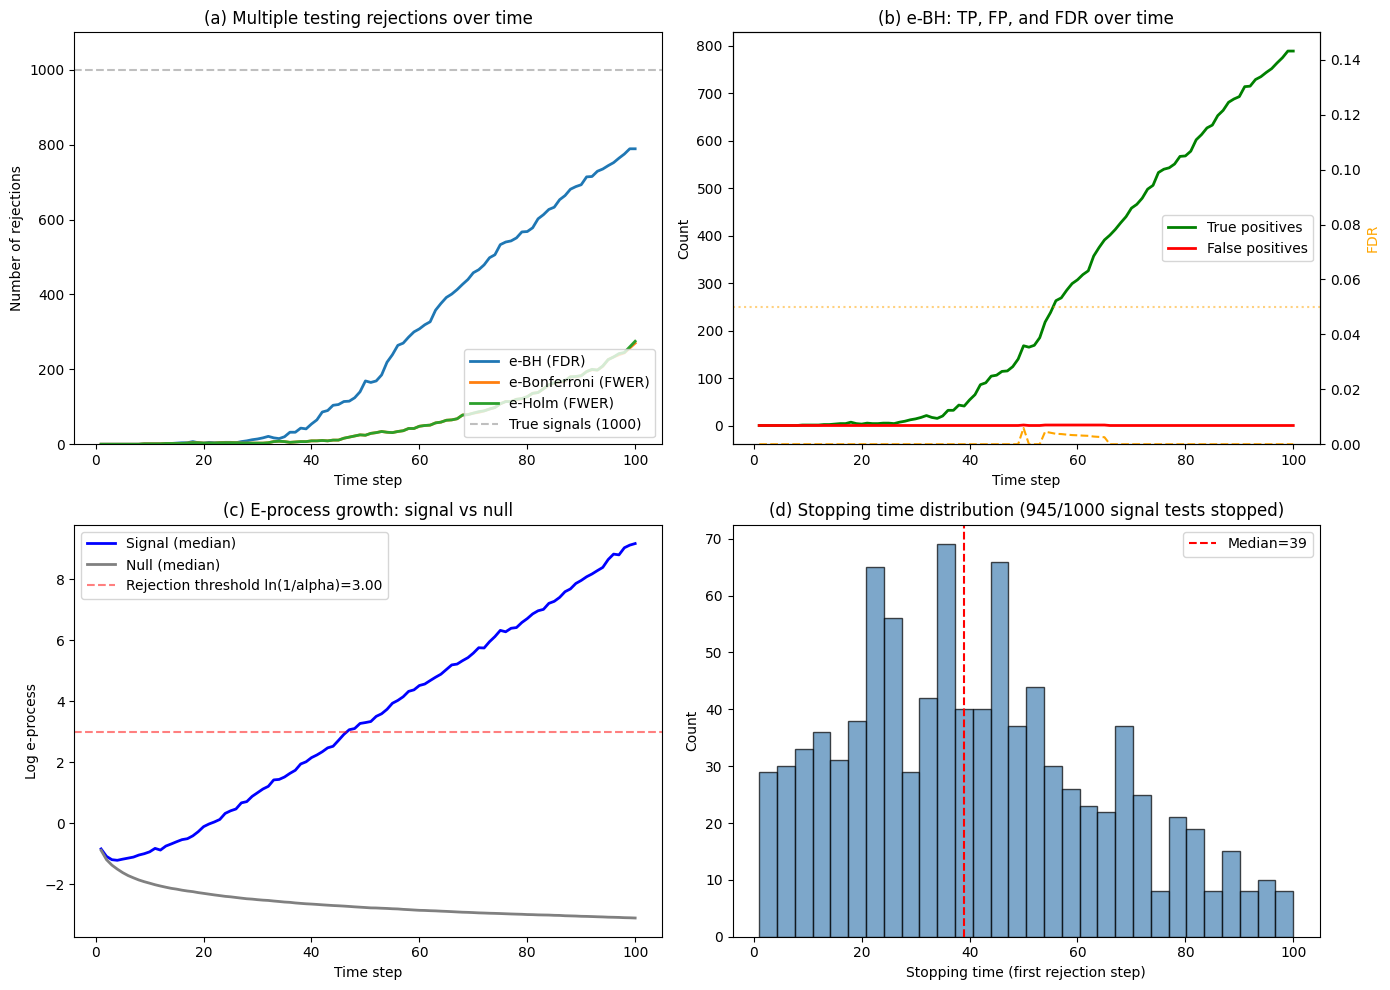

In [5]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
ts = history["time_step"]

# (a) Rejection curves over time
ax = axes[0, 0]
ax.plot(ts, history["n_rejected_bh"], label="e-BH (FDR)", linewidth=2)
ax.plot(ts, history["n_rejected_bonf"], label="e-Bonferroni (FWER)", linewidth=2)
ax.plot(ts, history["n_rejected_holm"], label="e-Holm (FWER)", linewidth=2)
ax.axhline(N_SIGNAL, color="gray", linestyle="--", alpha=0.5, label=f"True signals ({N_SIGNAL})")
ax.set_xlabel("Time step")
ax.set_ylabel("Number of rejections")
ax.set_title("(a) Multiple testing rejections over time")
ax.legend(loc="lower right")
ax.set_ylim(0, N_SIGNAL * 1.1)

# (b) True positives and false positives (e-BH)
ax = axes[0, 1]
ax.plot(ts, history["tp_bh"], label="True positives", linewidth=2, color="green")
ax.plot(ts, history["fp_bh"], label="False positives", linewidth=2, color="red")
fdr_over_time = [
    fp / (tp + fp) if (tp + fp) > 0 else 0.0
    for tp, fp in zip(history["tp_bh"], history["fp_bh"])
]
ax2 = ax.twinx()
ax2.plot(ts, fdr_over_time, label="FDR", linewidth=1.5, color="orange", linestyle="--")
ax2.axhline(ALPHA, color="orange", linestyle=":", alpha=0.5)
ax2.set_ylabel("FDR", color="orange")
ax2.set_ylim(0, 0.15)
ax.set_xlabel("Time step")
ax.set_ylabel("Count")
ax.set_title("(b) e-BH: TP, FP, and FDR over time")
ax.legend(loc="center right")

# (c) E-process growth: signal vs null
ax = axes[1, 0]
ax.plot(ts, history["median_log_ep_signal"], label="Signal (median)", linewidth=2, color="blue")
ax.plot(ts, history["median_log_ep_null"], label="Null (median)", linewidth=2, color="gray")
ax.axhline(np.log(1 / ALPHA), color="red", linestyle="--", alpha=0.5, label=f"Rejection threshold ln(1/alpha)={np.log(1/ALPHA):.2f}")
ax.set_xlabel("Time step")
ax.set_ylabel("Log e-process")
ax.set_title("(c) E-process growth: signal vs null")
ax.legend()

# (d) Stopping time distribution for signal tests
ax = axes[1, 1]
signal_stopped = stopping_times[:N_SIGNAL]
signal_stopped = signal_stopped[signal_stopped > 0]
if len(signal_stopped) > 0:
    ax.hist(signal_stopped, bins=30, edgecolor="black", alpha=0.7, color="steelblue")
    ax.axvline(np.median(signal_stopped), color="red", linestyle="--", label=f"Median={np.median(signal_stopped):.0f}")
    ax.legend()
ax.set_xlabel("Stopping time (first rejection step)")
ax.set_ylabel("Count")
ax.set_title(f"(d) Stopping time distribution ({len(signal_stopped)}/{N_SIGNAL} signal tests stopped)")

plt.tight_layout()
plt.show()

# 5. Compare Combiner Strategies

Run the same experiment with three different combiner strategies on a GREATER alternative:

- **ALL_IN** (Proposition 7.20): lambda=1, e-process = product of sequential e-values. Most powerful, but fragile.
- **CONSERVATIVE** (Definition 7.21): fixed lambda=0.5. More robust to misspecification.
- **EMPIRICALLY_ADAPTIVE** (Theorem 7.22): ONS-based lambda adapts to signal strength.

In [6]:
np.random.seed(123)

N_COMPARE = 5_000
N_SIG_COMPARE = 500
STEPS_COMPARE = 80

combiner_configs = {
    "ALL_IN": ParallelTestConfig(
        n_tests=N_COMPARE, alpha=0.05,
        alternative=AlternativeDirection.GREATER,
        combiner=CombinerStrategy.ALL_IN,
    ),
    "CONSERVATIVE (lambda=0.5)": ParallelTestConfig(
        n_tests=N_COMPARE, alpha=0.05,
        alternative=AlternativeDirection.GREATER,
        combiner=CombinerStrategy.CONSERVATIVE,
        conservative_lambda=0.5,
    ),
    "ADAPTIVE (gamma=0.5)": ParallelTestConfig(
        n_tests=N_COMPARE, alpha=0.05,
        alternative=AlternativeDirection.GREATER,
        combiner=CombinerStrategy.EMPIRICALLY_ADAPTIVE,
        gamma=0.5,
        epsilon=1e-6,
    ),
}

combiner_results = {}

for name, cfg in combiner_configs.items():
    # Note: GREATER auto-selects OneSidedNormalMixture
    engine = ParallelSequentialTest(config=cfg, null_values=0.0, variance=1.0)

    np.random.seed(123)  # same data for fair comparison
    bh_rejections = []
    median_log_ep = []

    for t in range(STEPS_COMPARE):
        obs = np.random.randn(N_COMPARE)
        obs[:N_SIG_COMPARE] += 0.4  # moderate signal
        engine.step(obs)
        bh = engine.e_bh()
        bh_rejections.append(bh.n_rejected)
        median_log_ep.append(np.median(engine.log_e_processes()[:N_SIG_COMPARE]))

    combiner_results[name] = {
        "bh_rejections": bh_rejections,
        "median_log_ep": median_log_ep,
        "final_lambdas": engine.lambdas()[:10].copy(),
        "final_p_values_signal": engine.p_values()[:N_SIG_COMPARE].copy(),
    }

    final_bh = engine.e_bh()
    assert final_bh.method == MultipleTestingMethod.E_BH
    tp = np.sum(final_bh.rejected[:N_SIG_COMPARE])
    fp = np.sum(final_bh.rejected[N_SIG_COMPARE:])
    fdr = fp / final_bh.n_rejected if final_bh.n_rejected > 0 else 0.0
    print(
        f"{name:35s} | e-BH: {final_bh.n_rejected:4d} rejections "
        f"(TP={tp}, FP={fp}, FDR={fdr:.4f}) | "
        f"lambdas[0:3]={engine.lambdas()[:3]}"
    )

ALL_IN                              | e-BH:  117 rejections (TP=117, FP=0, FDR=0.0000) | lambdas[0:3]=[1. 1. 1.]
CONSERVATIVE (lambda=0.5)           | e-BH:   82 rejections (TP=82, FP=0, FDR=0.0000) | lambdas[0:3]=[0.5 0.5 0.5]
ADAPTIVE (gamma=0.5)                | e-BH:    6 rejections (TP=6, FP=0, FDR=0.0000) | lambdas[0:3]=[0.34511165 0.32572613 0.5       ]


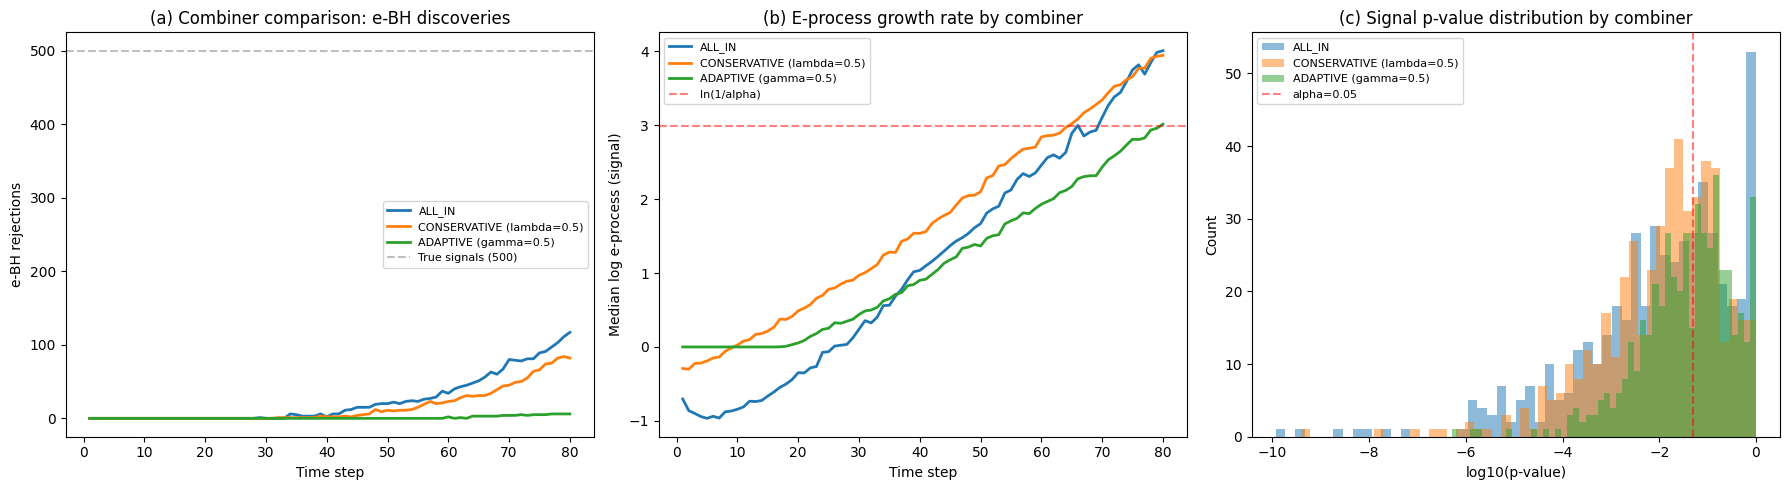

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
ts = list(range(1, STEPS_COMPARE + 1))

# (a) e-BH rejections over time
ax = axes[0]
for name, res in combiner_results.items():
    ax.plot(ts, res["bh_rejections"], label=name, linewidth=2)
ax.axhline(N_SIG_COMPARE, color="gray", linestyle="--", alpha=0.5, label=f"True signals ({N_SIG_COMPARE})")
ax.set_xlabel("Time step")
ax.set_ylabel("e-BH rejections")
ax.set_title("(a) Combiner comparison: e-BH discoveries")
ax.legend(fontsize=8)

# (b) Median log e-process for signal tests
ax = axes[1]
for name, res in combiner_results.items():
    ax.plot(ts, res["median_log_ep"], label=name, linewidth=2)
ax.axhline(np.log(1 / 0.05), color="red", linestyle="--", alpha=0.5, label="ln(1/alpha)")
ax.set_xlabel("Time step")
ax.set_ylabel("Median log e-process (signal)")
ax.set_title("(b) E-process growth rate by combiner")
ax.legend(fontsize=8)

# (c) P-value distribution for signal tests
ax = axes[2]
for name, res in combiner_results.items():
    pvals = res["final_p_values_signal"]
    pvals_log = np.log10(pvals + 1e-300)
    ax.hist(pvals_log, bins=50, alpha=0.5, label=name)
ax.axvline(np.log10(0.05), color="red", linestyle="--", alpha=0.5, label="alpha=0.05")
ax.set_xlabel("log10(p-value)")
ax.set_ylabel("Count")
ax.set_title("(c) Signal p-value distribution by combiner")
ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

# 6. One-Sided vs Two-Sided: GREATER and LESS Alternatives

Compare the three alternative directions on data with a positive shift (mu=0.3):
- **TWO_SIDED**: detects any deviation from null
- **GREATER**: optimized for positive shift (should be most powerful here)
- **LESS**: tests for negative shift (should fail to detect positive signal)

TWO_SIDED    | e-BH:    0 (TP=0, FP=0)
GREATER      | e-BH:    0 (TP=0, FP=0)
LESS         | e-BH:    0 (TP=0, FP=0)


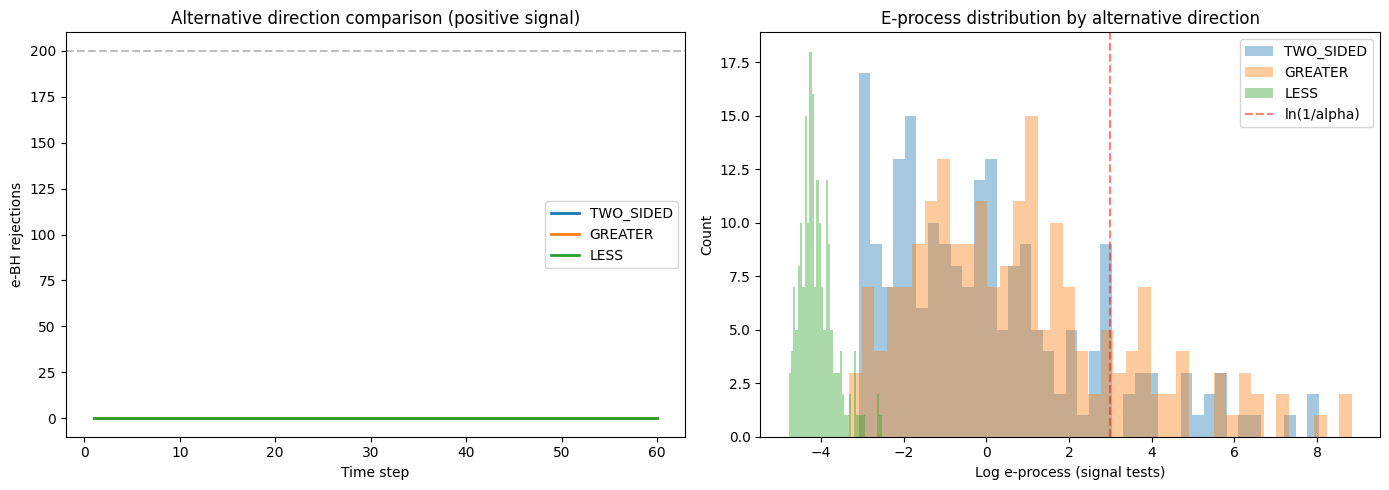

In [8]:
N_DIR = 2_000
N_SIG_DIR = 200
STEPS_DIR = 60

alternatives = {
    "TWO_SIDED": AlternativeDirection.TWO_SIDED,
    "GREATER": AlternativeDirection.GREATER,
    "LESS": AlternativeDirection.LESS,
}

dir_results = {}

for label, alt in alternatives.items():
    cfg = ParallelTestConfig(
        n_tests=N_DIR, alpha=0.05,
        alternative=alt,
        combiner=CombinerStrategy.ALL_IN,
    )
    engine = ParallelSequentialTest(config=cfg, null_values=0.0, variance=1.0)

    np.random.seed(999)
    bh_over_time = []
    for t in range(STEPS_DIR):
        obs = np.random.randn(N_DIR)
        obs[:N_SIG_DIR] += 0.3  # positive shift
        engine.step(obs)
        bh_over_time.append(engine.e_bh().n_rejected)

    dir_results[label] = {
        "bh_over_time": bh_over_time,
        "log_ep_signal": engine.log_e_processes()[:N_SIG_DIR].copy(),
        "stopping_times": engine.stopping_times()[:N_SIG_DIR].copy(),
    }

    bh_final = engine.e_bh()
    tp = np.sum(bh_final.rejected[:N_SIG_DIR])
    fp = np.sum(bh_final.rejected[N_SIG_DIR:])
    print(f"{label:12s} | e-BH: {bh_final.n_rejected:4d} (TP={tp}, FP={fp})")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
ts = list(range(1, STEPS_DIR + 1))

ax = axes[0]
for label, res in dir_results.items():
    ax.plot(ts, res["bh_over_time"], label=label, linewidth=2)
ax.axhline(N_SIG_DIR, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Time step")
ax.set_ylabel("e-BH rejections")
ax.set_title("Alternative direction comparison (positive signal)")
ax.legend()

ax = axes[1]
for label, res in dir_results.items():
    ax.hist(res["log_ep_signal"], bins=40, alpha=0.4, label=label)
ax.axvline(np.log(1 / 0.05), color="red", linestyle="--", alpha=0.5, label="ln(1/alpha)")
ax.set_xlabel("Log e-process (signal tests)")
ax.set_ylabel("Count")
ax.set_title("E-process distribution by alternative direction")
ax.legend()

plt.tight_layout()
plt.show()

# 7. Performance: Scale to Millions of Tests

In [10]:
import time

print(f"{'n_tests':>12s} | {'step (ms)':>10s} | {'ns/test':>8s} | {'e-BH (ms)':>10s} | {'combiner':>25s}")
print("-" * 75)

for n in [1_000, 10_000, 100_000, 300_000, 1_000_000]:
    for comb in [CombinerStrategy.ALL_IN, CombinerStrategy.CONSERVATIVE, CombinerStrategy.EMPIRICALLY_ADAPTIVE]:
        cfg = ParallelTestConfig(
            n_tests=n, alpha=0.05,
            alternative=AlternativeDirection.GREATER,
            combiner=comb,
            gamma=0.5, epsilon=1e-6,
        )
        engine = ParallelSequentialTest(config=cfg, null_values=0.0, variance=1.0)
        obs = np.random.randn(n)
        engine.step(obs)  # warm up

        iters = 20
        start = time.perf_counter()
        for _ in range(iters):
            engine.step(obs)
        step_ms = (time.perf_counter() - start) / iters * 1000

        start = time.perf_counter()
        for _ in range(iters):
            engine.e_bh()
        bh_ms = (time.perf_counter() - start) / iters * 1000

        ns_per = step_ms * 1e6 / n
        print(f"{n:>12,} | {step_ms:>10.2f} | {ns_per:>8.1f} | {bh_ms:>10.2f} | {comb.value:>25s}")

     n_tests |  step (ms) |  ns/test |  e-BH (ms) |                  combiner
---------------------------------------------------------------------------
       1,000 |       0.12 |    117.4 |       0.01 |                    all_in
       1,000 |       0.15 |    147.2 |       0.02 |              conservative
       1,000 |       0.13 |    131.0 |       0.01 |      empirically_adaptive
      10,000 |       0.80 |     80.3 |       0.18 |                    all_in
      10,000 |       0.58 |     57.9 |       0.11 |              conservative
      10,000 |       0.61 |     61.5 |       0.09 |      empirically_adaptive
     100,000 |       3.57 |     35.7 |       1.74 |                    all_in
     100,000 |       3.73 |     37.3 |       0.97 |              conservative
     100,000 |       3.22 |     32.2 |       0.88 |      empirically_adaptive
     300,000 |      10.91 |     36.4 |       3.62 |                    all_in
     300,000 |      10.61 |     35.4 |       2.45 |              c